<div style="padding:28px 32px;border-radius:18px;background:linear-gradient(135deg,#0b1020,#161b33 55%,#122b34);color:#f5f7ff;border:1px solid #2c3557">
<h1 style="margin:0;font-size:40px">Entangle: The Quantum Odyssey</h1>
<p style="font-size:20px;margin:8px 0 0">End-to-End Hands-On Quantum Computing Workshop with Qiskit Aer</p>
<p style="opacity:.8;margin-top:16px">Silver Oak University IEEE Computer Society | Presented by Ashish Patel</p>
</div>

## How to use this notebook

This notebook is designed to be run **top to bottom** during the workshop. Use **Run All** after the environment is ready, or run one lab at a time with the instructor.

**Workshop rule:** predict first, run second, explain third.

### Learning outcomes
By the end, you should be able to:
- explain bits, qubits, amplitudes, phase, superposition, measurement, interference and entanglement;
- explain what common quantum gates mean and how they transform a state;
- build and simulate circuits with `QuantumCircuit`, `transpile`, and `AerSimulator`;
- interpret shots, jobs, results, counts and histograms;
- inspect a simulated statevector;
- build a Bell pair, a 2-qubit Grover search, and a circuit-based random-bit generator;
- distinguish ideal simulation, noisy simulation, and execution on a physical QPU.

# 0. Environment setup

Recommended workshop environment:
- Python 3.10 or newer
- Qiskit 2.x
- Qiskit Aer 0.17 or newer
- Matplotlib
- Jupyter Notebook / JupyterLab

The next two cells bootstrap `uv`, then use it to install workshop packages only if they are missing. If your workshop machine is offline, install the packages in advance.

In [ ]:
!uv add "qiskit>=2.5.2" "qiskit-aer>=0.17" matplotlib numpy pylatexenc jupyter notebook

In [26]:
# Run this after the uv bootstrap cell. It installs only missing workshop packages.
import importlib.util
import subprocess
import sys

required = {
    "qiskit": "qiskit",
    "qiskit_aer": "qiskit-aer",
    "matplotlib": "matplotlib",
    "numpy": "numpy",
    "pylatexenc": "pylatexenc",  # required by circuit.draw('mpl')
}

missing = [pip_name for module, pip_name in required.items()
           if importlib.util.find_spec(module) is None]

if missing:
    print("Installing missing packages:", ", ".join(missing))
    uv_install = [
        sys.executable, "-m", "uv", "pip", "install",
        "--python", sys.executable, *missing
    ]
    try:
        subprocess.check_call(uv_install)
    except (subprocess.CalledProcessError, ModuleNotFoundError):
        print("uv could not install into this kernel; falling back to pip.")
        subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
    print("Installation complete. Restart the kernel only if an import still fails.")
else:
    print("All workshop packages are already installed.")

All workshop packages are already installed.


In [27]:
# Environment check and common imports
import sys
import math
import numpy as np
import matplotlib.pyplot as plt
import qiskit
import qiskit_aer

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_bloch_multivector
from IPython.display import display

print("Python:", sys.version.split()[0])
print("Qiskit:", qiskit.__version__)
print("Qiskit Aer:", qiskit_aer.__version__)
print("Environment ready.")

Python: 3.14.5
Qiskit: 2.5.2
Qiskit Aer: 0.17.2
Environment ready.


## Core execution vocabulary

| Term | Meaning |
|---|---|
| **QuantumCircuit** | Ordered quantum and classical instructions that describe an experiment. |
| **Qubit** | Basic quantum information unit. A pure qubit state can be written as $|\psi\rangle=\alpha|0\rangle+\beta|1\rangle$. |
| **Classical bit** | Ordinary 0/1 memory used to store measurement outcomes. |
| **Gate** | Reversible operation that transforms quantum amplitudes and phases. |
| **Backend** | Execution target. In this workshop it is usually `AerSimulator`. |
| **Transpilation** | Rewriting/optimizing a circuit for the operations and constraints of a backend. |
| **Job** | Submitted execution request. |
| **Result** | Returned execution data. |
| **Shots** | Number of repeated samples of a measured circuit. |
| **Counts** | Dictionary of measured bitstrings and how often each appeared. |
| **Statevector** | $2^n$ complex amplitudes describing an ideal pure state of $n$ simulated qubits. |

In [28]:
# Shared helpers used throughout the notebook
DEFAULT_SHOTS = 1024
DEFAULT_SEED = 42
SIMULATOR = AerSimulator()


def run_counts(circuit, shots=DEFAULT_SHOTS, seed=DEFAULT_SEED, simulator=None):
    """Transpile and sample a measured circuit on AerSimulator."""
    simulator = simulator or SIMULATOR
    compiled = transpile(circuit, simulator, optimization_level=0)
    kwargs = {"shots": shots}
    if seed is not None:
        kwargs["seed_simulator"] = seed
    job = simulator.run(compiled, **kwargs)
    result = job.result()
    return result.get_counts(), compiled, job, result


def aer_statevector(circuit):
    """Return the ideal simulated statevector before measurement."""
    qc = circuit.copy()
    qc.save_statevector()
    sim = AerSimulator(method="statevector")
    compiled = transpile(qc, sim)
    result = sim.run(compiled).result()
    return np.asarray(result.get_statevector(compiled), dtype=complex)


def show_statevector(state, labels=None, title="Statevector amplitudes"):
    """Print amplitudes and visualize probability plus relative phase."""
    state = np.asarray(state, dtype=complex)
    labels = labels or [format(i, f"0{int(math.log2(len(state))) if len(state) > 1 else 1}b")
                        for i in range(len(state))]
    probabilities = np.abs(state) ** 2
    phases = np.angle(state)
    print(title)
    for label, amp in zip(labels, state):
        print(f"|{label}> : {amp.real:+.4f}{amp.imag:+.4f}j   P={abs(amp)**2:.4f}")

    colors = plt.cm.cool(np.linspace(0.12, 0.88, len(labels)))
    fig, (prob_ax, phase_ax) = plt.subplots(1, 2, figsize=(10, 3.6))
    prob_bars = prob_ax.bar(labels, probabilities, color=colors, edgecolor="#20243b")
    prob_ax.set_title(f"{title}: measurement probabilities")
    prob_ax.set_xlabel("Computational-basis state")
    prob_ax.set_ylabel("Probability")
    prob_ax.set_ylim(0, 1.08)
    prob_ax.bar_label(prob_bars, fmt="%.3f", padding=3)

    phase_bars = phase_ax.bar(labels, phases, color=colors, edgecolor="#20243b")
    phase_ax.set_title("Amplitude phase (relative information)")
    phase_ax.set_xlabel("Computational-basis state")
    phase_ax.set_ylabel("Phase in radians")
    phase_ax.set_ylim(-np.pi, np.pi)
    phase_ax.set_yticks(
        [-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi],
        ["-π", "-π/2", "0", "π/2", "π"]
    )
    phase_ax.axhline(0, color="#606782", linewidth=0.8)
    phase_ax.bar_label(phase_bars, fmt="%.2f", padding=3)
    fig.suptitle("Exact ideal statevector simulation", fontsize=10, color="#555b73")
    fig.tight_layout()
    plt.show()


def show_counts(counts, title="Measurement counts"):
    print(counts)
    display(plot_histogram(counts, title=title))

# Foundations - Where quantum computing fits

## A brief history in seven moments

| Year | Milestone | Why it matters |
|---|---|---|
| **1900** | Planck introduces discrete energy quanta | The word "quantum" enters physics. |
| **1925-26** | Modern quantum mechanics is formulated | States, amplitudes, observables and probability become a predictive framework. |
| **1935** | EPR and Schrodinger's entanglement discussion | Quantum correlations become impossible to ignore. |
| **1982** | Feynman proposes quantum simulation | Motivation: simulate quantum physics with quantum systems. |
| **1985** | Deutsch describes a universal quantum computer | Quantum computation becomes a general computational model. |
| **1994** | Shor's factoring algorithm | Shows dramatic algorithmic implications for public-key cryptography on future fault-tolerant machines. |
| **1996** | Grover's search algorithm | Demonstrates quadratic query improvement for unstructured search. |

Quantum computers are **specialized accelerators**, not replacement laptops. The goal is to exploit quantum structure for particular problems.

## Classical computer anatomy

- **Transistor** - physical switching element used to build digital logic.
- **Logic gate** - Boolean operation such as AND, OR or NOT.
- **CPU** - executes instructions and coordinates computation.
- **Memory (RAM)** - fast volatile workspace for active programs and data.
- **Storage** - persistent data retained after power is removed.

A classical program transforms stable bit patterns through deterministic logic.

## Quantum computer anatomy

- **Classical host** - constructs circuits, schedules work and analyzes results.
- **Control electronics** - convert digital instructions into calibrated physical control signals.
- **Cryogenic / isolation system** - maintains an environment suitable for some qubit technologies, especially superconducting qubits.
- **QPU** - physical quantum processor containing qubits and couplers.
- **Readout chain** - converts weak physical signals into classical 0/1 outcomes.

A typical workflow is hybrid:

**classical plan -> quantum evolution -> classical measurement and analysis**

## Classical vs quantum mental model

| Classical | Quantum |
|---|---|
| bit: 0 or 1 | qubit: amplitudes + relative phase |
| Boolean logic | unitary quantum gates |
| bits can be copied freely | unknown quantum states cannot be perfectly cloned |
| reading a modeled bit can be non-destructive | quantum measurement generally changes the state |
| deterministic logic plus classical randomness when needed | coherent evolution, interference and probabilistic measurement |

**Key idea:** quantum advantage is not "trying every answer and reading them all." Useful algorithms engineer interference so desired outcomes become more likely to measure.

# Part I - From bits to qubits

## 1. Classical bit
A classical bit has one logical value at a time: **0 or 1**. A NOT operation flips it.

In [29]:
bit = 0
print("start:", bit)
bit = 1 - bit
print("NOT  :", bit)
bit = 1 - bit
print("NOT  :", bit)

start: 0
NOT  : 1
NOT  : 0


## 2. Qubit

A pure qubit state is

$$|\psi\rangle = \alpha|0\rangle + \beta|1\rangle$$

with

$$|\alpha|^2 + |\beta|^2 = 1.$$

- **Amplitude**: complex coefficient such as $\alpha$ or $\beta$.
- **Probability**: squared magnitude of an amplitude.
- **Phase**: relative complex angle between amplitudes; it can change later interference even when immediate measurement probabilities are unchanged.
- **Computational basis**: the states $|0\rangle$ and $|1\rangle$ used for ordinary Z-basis measurement.
- **Superposition**: coherent combination of basis states, not an ordinary hidden classical coin flip.

Initial qubit
|0> : +1.0000+0.0000j   P=1.0000
|1> : +0.0000+0.0000j   P=0.0000


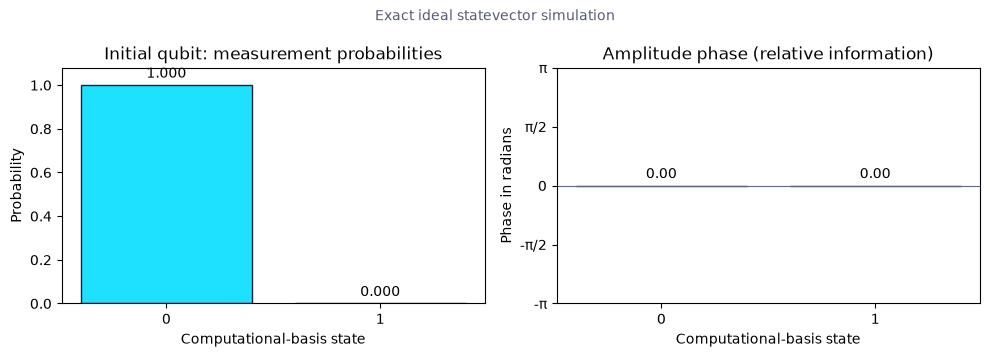

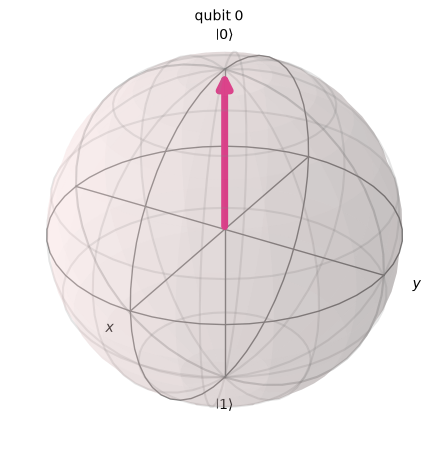

In [30]:
# A fresh Qiskit qubit starts in |0>.
qc_zero = QuantumCircuit(1)
psi_zero = aer_statevector(qc_zero)
show_statevector(psi_zero, ["0", "1"], "Initial qubit")
display(plot_bloch_multivector(psi_zero))

# Part II - Quantum gates: meaning, math, simulation

A **quantum gate** is a reversible transformation. For a single pure qubit, many gates can be visualized as rotations of the Bloch sphere.

| Gate | Plain meaning | Main action | Qiskit |
|---|---|---|---|
| **X** | Quantum NOT / bit flip | $|0\rangle \leftrightarrow |1\rangle$ | `qc.x(0)` |
| **Y** | Bit flip plus phase | Rotation by $\pi$ around Y | `qc.y(0)` |
| **Z** | Phase flip | Changes sign of the $|1\rangle$ amplitude | `qc.z(0)` |
| **H** | Superposition / basis change | $|0\rangle\to|+\rangle$, $|1\rangle\to| - \rangle$ | `qc.h(0)` |
| **S** | Quarter-phase gate | Z rotation by $\pi/2$ | `qc.s(0)` |
| **T** | Eighth-phase gate | Z rotation by $\pi/4$ | `qc.t(0)` |
| **Rx(theta)** | Tunable X rotation | Continuous rotation around X | `qc.rx(theta, 0)` |
| **CX / CNOT** | Controlled NOT | Flip target only when control is 1 | `qc.cx(control, target)` |

## 3. X gate - quantum NOT

Matrix:
$$X=\begin{bmatrix}0&1\\1&0\end{bmatrix}$$

It swaps the computational-basis states. From $|0\rangle$, X produces $|1\rangle$ exactly.

After X
|0> : +0.0000+0.0000j   P=0.0000
|1> : +1.0000+0.0000j   P=1.0000


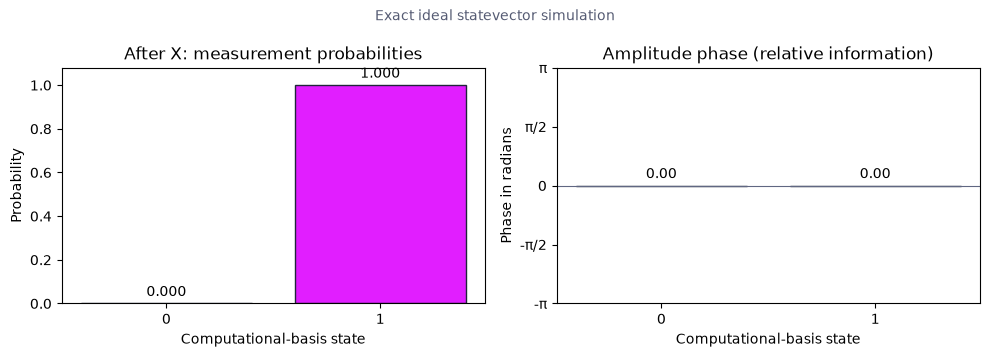

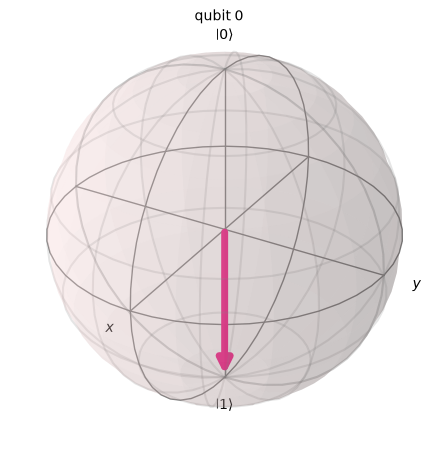

{'1': 100}


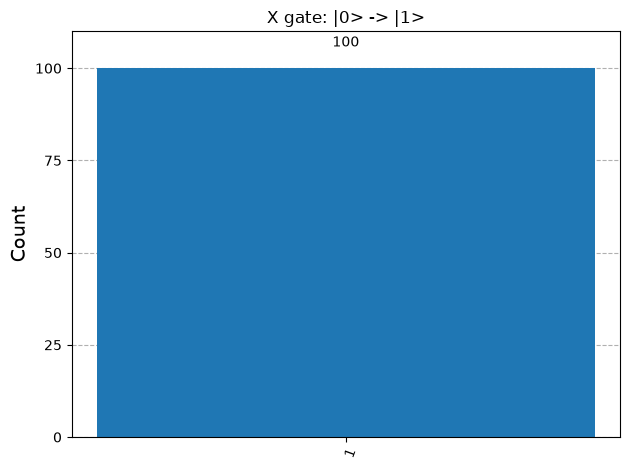

In [31]:
qc_x_state = QuantumCircuit(1)
qc_x_state.x(0)
psi_x = aer_statevector(qc_x_state)
show_statevector(psi_x, ["0", "1"], "After X")
display(plot_bloch_multivector(psi_x))

qc_x = QuantumCircuit(1, 1)
qc_x.x(0)
qc_x.measure(0, 0)
counts_x, *_ = run_counts(qc_x, shots=100)
show_counts(counts_x, "X gate: |0> -> |1>")

## 4. Y gate - bit flip plus phase

Matrix:
$$Y=\begin{bmatrix}0&-i\\i&0\end{bmatrix}$$

Starting from $|0\rangle$, Y reaches the south pole like X, but the state carries a different phase. That phase can matter when the state later interferes.

After Y
|0> : +0.0000-0.0000j   P=0.0000
|1> : +0.0000+1.0000j   P=1.0000


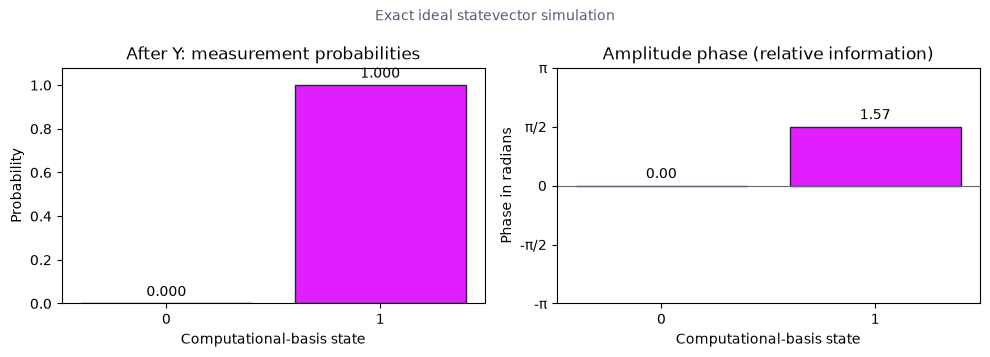

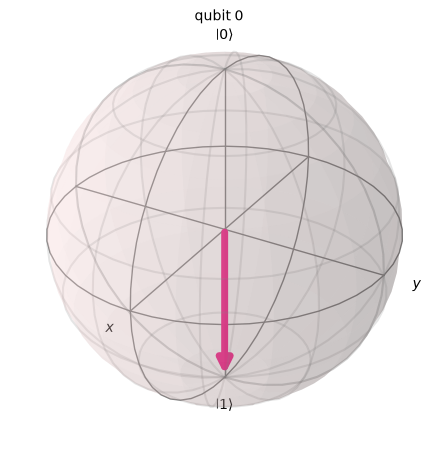

In [32]:
qc_y = QuantumCircuit(1)
qc_y.y(0)
psi_y = aer_statevector(qc_y)
show_statevector(psi_y, ["0", "1"], "After Y")
display(plot_bloch_multivector(psi_y))

## 5. Z gate - phase flip

Matrix:
$$Z=\begin{bmatrix}1&0\\0&-1\end{bmatrix}$$

Z does not swap $|0\rangle$ and $|1\rangle$. It changes the **relative phase** of the $|1\rangle$ component. On $|+\rangle$, Z creates $|-\rangle$.

Before Z: |+>
|0> : +0.7071+0.0000j   P=0.5000
|1> : +0.7071+0.0000j   P=0.5000


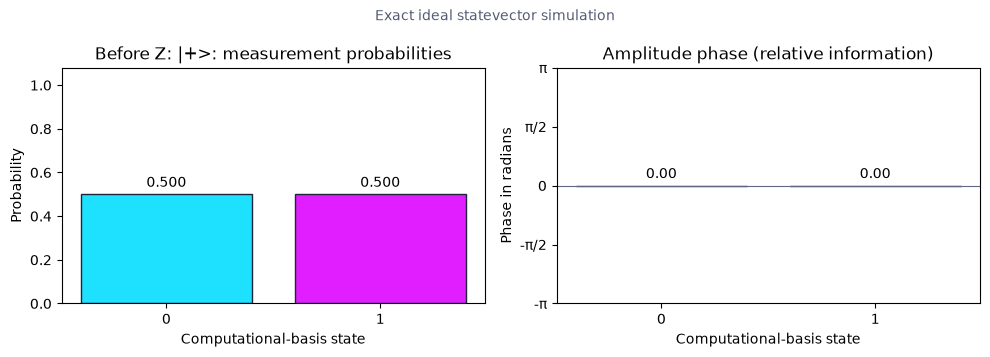

After Z: |->
|0> : +0.7071+0.0000j   P=0.5000
|1> : -0.7071-0.0000j   P=0.5000


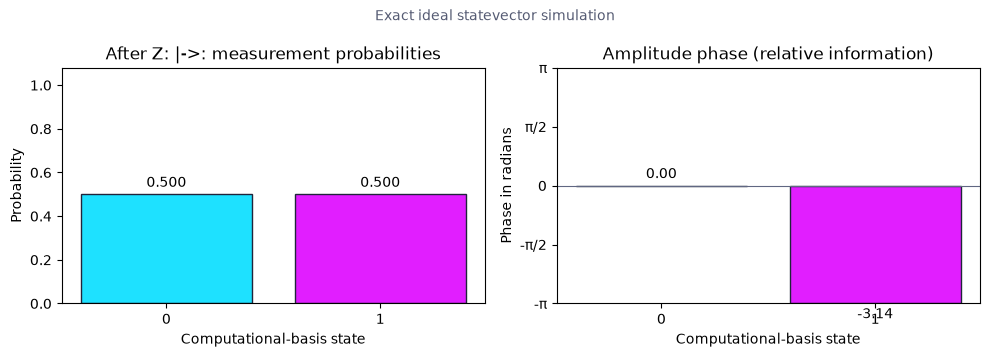

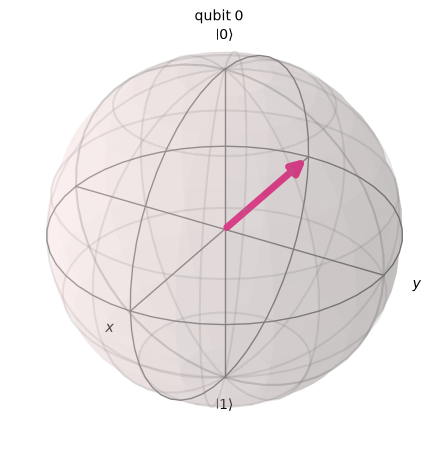

In [33]:
qc_z = QuantumCircuit(1)
qc_z.h(0)  # |0> -> |+>
psi_before_z = aer_statevector(qc_z)

qc_z.z(0)  # |+> -> |->
psi_after_z = aer_statevector(qc_z)

show_statevector(psi_before_z, ["0", "1"], "Before Z: |+>")
show_statevector(psi_after_z, ["0", "1"], "After Z: |->")
display(plot_bloch_multivector(psi_after_z))

## 6. H gate - superposition and basis change

Matrix:
$$H=\frac{1}{\sqrt{2}}\begin{bmatrix}1&1\\1&-1\end{bmatrix}$$

Important mappings:

$$H|0\rangle=|+\rangle=\frac{|0\rangle+|1\rangle}{\sqrt2}$$
$$H|1\rangle=|-\rangle=\frac{|0\rangle-|1\rangle}{\sqrt2}$$

H is not merely a 'randomness gate'. It creates or recombines coherent paths, which is why it is central to interference, Bell states and Grover search.

After H
|0> : +0.7071+0.0000j   P=0.5000
|1> : +0.7071+0.0000j   P=0.5000


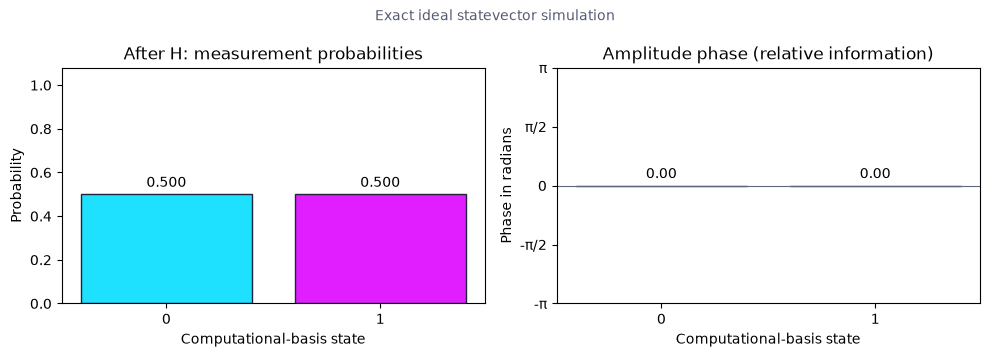

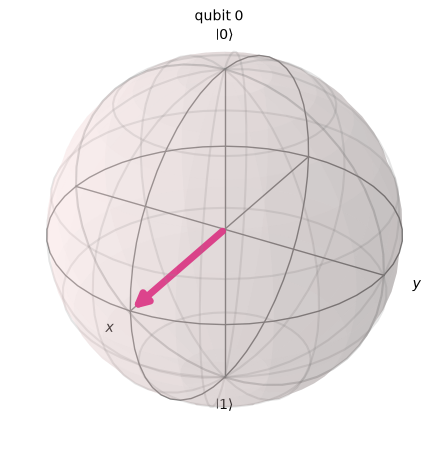

{'0': 514, '1': 486}


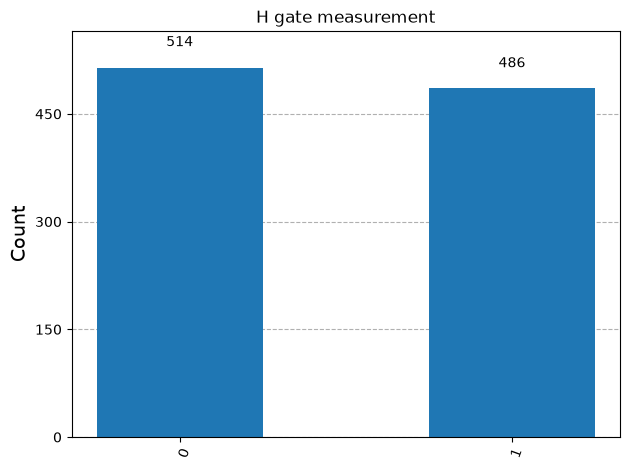

In [34]:
qc_h_state = QuantumCircuit(1)
qc_h_state.h(0)
psi_h = aer_statevector(qc_h_state)
show_statevector(psi_h, ["0", "1"], "After H")
display(plot_bloch_multivector(psi_h))

qc_h = QuantumCircuit(1, 1)
qc_h.h(0)
qc_h.measure(0, 0)
counts_h, *_ = run_counts(qc_h, shots=1000)
show_counts(counts_h, "H gate measurement")

## 7. S and T gates - phase steering

$$S=\begin{bmatrix}1&0\\0&i\end{bmatrix},\qquad
T=\begin{bmatrix}1&0\\0&e^{i\pi/4}\end{bmatrix}$$

Both rotate around the Z axis. They normally do **not** change immediate Z-basis probabilities, but they change relative phase.

After H then S
|0> : +0.7071+0.0000j   P=0.5000
|1> : +0.0000+0.7071j   P=0.5000


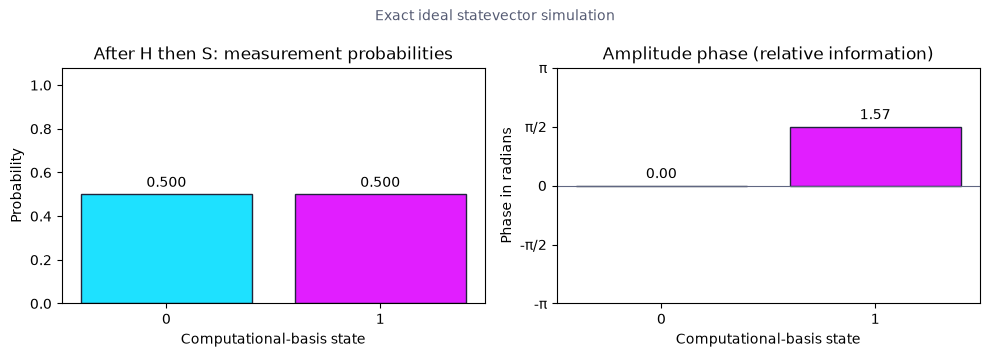

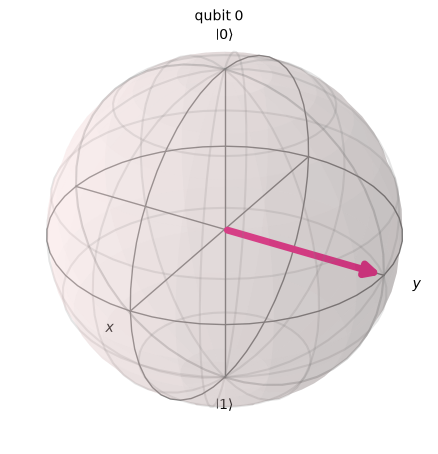

After H then T
|0> : +0.7071+0.0000j   P=0.5000
|1> : +0.5000+0.5000j   P=0.5000


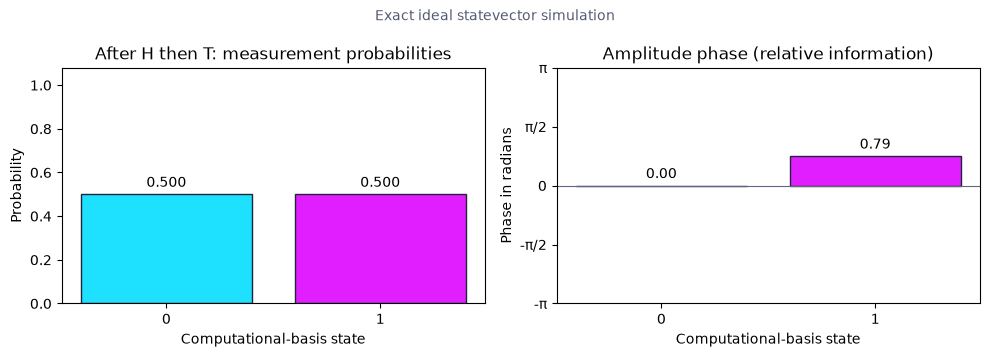

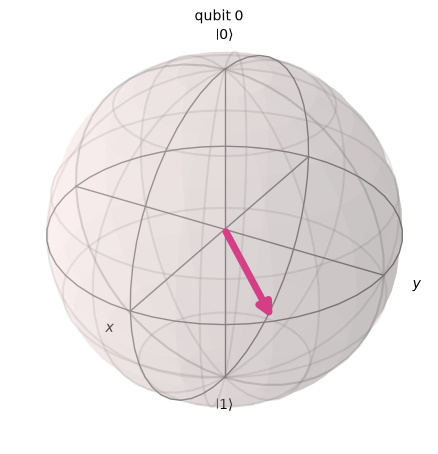

In [35]:
# Prepare |+>, then compare S and T phase rotations.
for gate_name in ["S", "T"]:
    qc = QuantumCircuit(1)
    qc.h(0)
    if gate_name == "S":
        qc.s(0)
    else:
        qc.t(0)
    psi = aer_statevector(qc)
    show_statevector(psi, ["0", "1"], f"After H then {gate_name}")
    display(plot_bloch_multivector(psi))

## 8. Rx(theta) - parameterized rotation

$$R_x(\theta)=\cos(\theta/2)I-i\sin(\theta/2)X$$

Unlike X, which is a fixed half-turn, `Rx` lets us choose the rotation angle. Parameterized rotations are common in variational and hybrid quantum algorithms.

After Rx(pi/2)
|0> : +0.7071+0.0000j   P=0.5000
|1> : +0.0000-0.7071j   P=0.5000


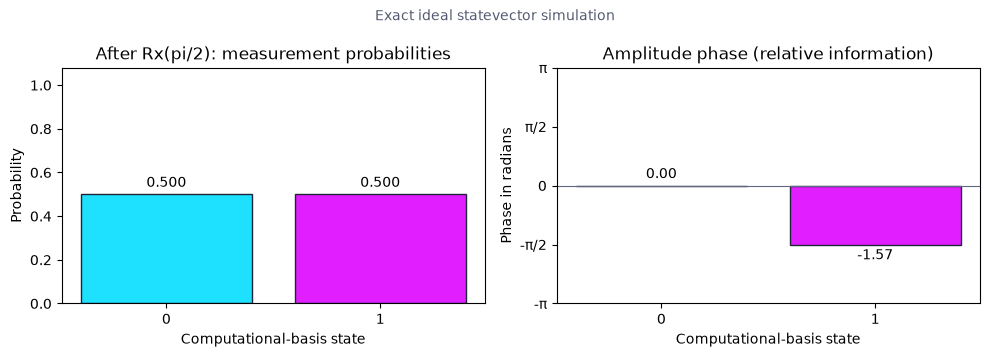

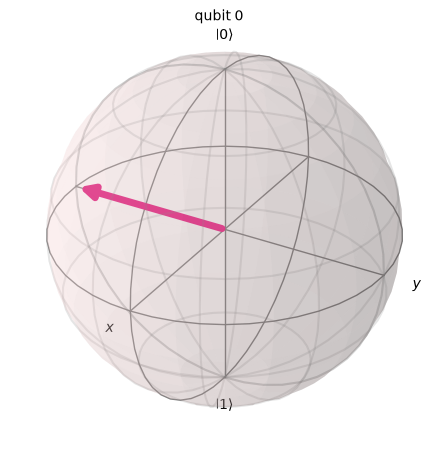

In [36]:
theta = np.pi / 2
qc_rx = QuantumCircuit(1)
qc_rx.rx(theta, 0)
psi_rx = aer_statevector(qc_rx)
show_statevector(psi_rx, ["0", "1"], "After Rx(pi/2)")
display(plot_bloch_multivector(psi_rx))

## 9. CX / CNOT - controlled NOT

CNOT has two qubits:
- **control**: decides whether the operation activates;
- **target**: flips only if the control is $|1\rangle$ on computational-basis input.

Basis-state action:

| Input | Output |
|---|---|
| 00 | 00 |
| 01 | 01 |
| 10 | 11 |
| 11 | 10 |

On superposition inputs, CNOT can create **entanglement**, which has no classical-bit equivalent.

{'11': 100}


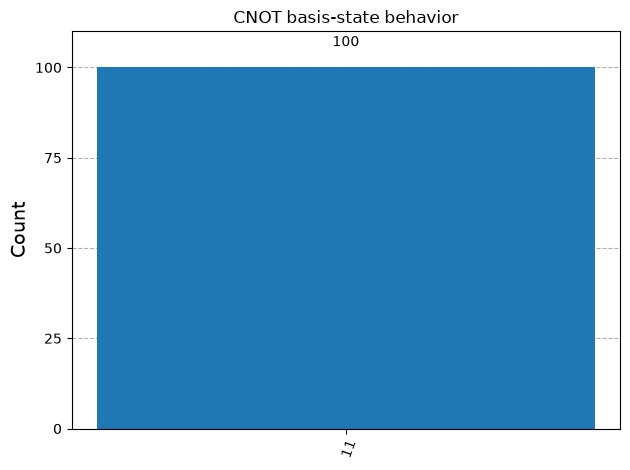

In [37]:
# Basis-state demonstration: prepare |10> in Qiskit's qubit ordering.
# We put q0=0 and q1=1, then apply CX(control=q1, target=q0).
qc_cx = QuantumCircuit(2, 2)
qc_cx.x(1)
qc_cx.cx(1, 0)
qc_cx.measure([0, 1], [0, 1])
counts_cx, *_ = run_counts(qc_cx, shots=100)
show_counts(counts_cx, "CNOT basis-state behavior")

# Part III - Measurement, shots and interference

## 10. Measurement
Measurement converts quantum information into a classical outcome. In the computational basis, a single shot returns a bitstring such as `0`, `1`, `00`, or `11`.

The **Born rule** connects amplitude to probability:

$$P(0)=|\alpha|^2, \qquad P(1)=|\beta|^2.$$

shots=   10 -> P(0)~0.500, P(1)~0.500
shots=  100 -> P(0)~0.490, P(1)~0.510
shots= 1000 -> P(0)~0.514, P(1)~0.486
shots=10000 -> P(0)~0.492, P(1)~0.508


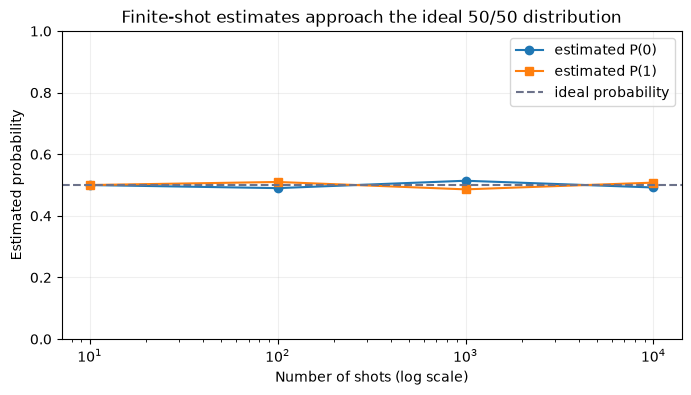

In [38]:
# Watch finite-shot estimates stabilize as the number of shots increases.
qc_measure = QuantumCircuit(1, 1)
qc_measure.h(0)
qc_measure.measure(0, 0)

shot_sizes = [10, 100, 1000, 10000]
p0_estimates = []
p1_estimates = []

for shots in shot_sizes:
    counts, *_ = run_counts(qc_measure, shots=shots, seed=42)
    p0 = counts.get("0", 0) / shots
    p1 = counts.get("1", 0) / shots
    p0_estimates.append(p0)
    p1_estimates.append(p1)
    print(f"shots={shots:5d} -> P(0)~{p0:.3f}, P(1)~{p1:.3f}")

plt.figure(figsize=(8, 4))
plt.semilogx(shot_sizes, p0_estimates, "o-", label="estimated P(0)")
plt.semilogx(shot_sizes, p1_estimates, "s-", label="estimated P(1)")
plt.axhline(0.5, color="#6c728a", linestyle="--", label="ideal probability")
plt.ylim(0, 1)
plt.xlabel("Number of shots (log scale)")
plt.ylabel("Estimated probability")
plt.title("Finite-shot estimates approach the ideal 50/50 distribution")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## 11. Interference - phase becomes measurable

Two circuits can have equal 50/50 probabilities in the middle but produce completely different final results.

- `H -> H` returns $|0\rangle$.
- `H -> Z -> H` returns $|1\rangle$.

The Z gate changes phase; the final H converts that phase difference into a probability difference.

H-H counts   : {'0': 500}
H-Z-H counts : {'1': 500}


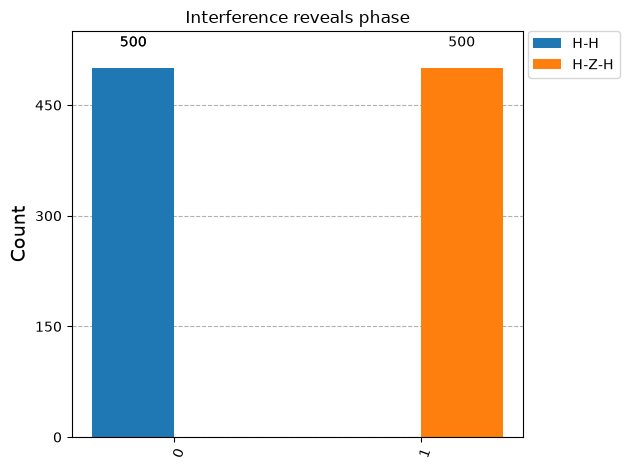

In [39]:
def interference_experiment(with_z=False, shots=500):
    qc = QuantumCircuit(1, 1)
    qc.h(0)
    if with_z:
        qc.z(0)
    qc.h(0)
    qc.measure(0, 0)
    counts, *_ = run_counts(qc, shots=shots)
    return qc, counts

qc_hh, counts_hh = interference_experiment(False)
qc_hzh, counts_hzh = interference_experiment(True)

print("H-H counts   :", counts_hh)
print("H-Z-H counts :", counts_hzh)
display(plot_histogram([counts_hh, counts_hzh], legend=["H-H", "H-Z-H"], title="Interference reveals phase"))

# Part IV - Qiskit Aer execution workflow

## 12. What actually happens when a circuit runs?

`QuantumCircuit -> transpile() -> AerSimulator -> job -> result -> counts`

- **Circuit construction**: describe the experiment.
- **Transpilation**: convert the abstract circuit into a form suitable for the backend.
- **Backend run**: submit the compiled experiment.
- **Job**: execution request object.
- **Result**: completed execution data.
- **Counts**: frequency table for measured outcomes.

In [40]:
qc_workflow = QuantumCircuit(1, 1)
qc_workflow.h(0)
qc_workflow.measure(0, 0)

backend = AerSimulator()
compiled = transpile(qc_workflow, backend)
job = backend.run(compiled, shots=256, seed_simulator=42)
result = job.result()
counts = result.get_counts()

print("Backend :", backend.name)
print("Job     :", type(job).__name__)
print("Result  :", type(result).__name__)
print("Counts  :", counts)

Backend : aer_simulator
Job     : AerJob
Result  : Result
Counts  : {'0': 141, '1': 115}


## 13. Circuit visualization
Qiskit can draw the logical circuit before execution. The diagram is read left to right.

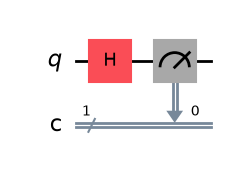

In [41]:
display(qc_workflow.draw("mpl"))

## 14. Statevector inspection

A statevector stores the complex amplitudes of an ideal simulated pure state. For $n$ qubits it contains $2^n$ amplitudes, so memory grows exponentially.

**Important:** a simulator can expose its internal statevector because the classical computer is calculating it. A physical QPU does not let us simply read an unknown full statevector from one run.

Statevector of |+>
|0> : +0.7071+0.0000j   P=0.5000
|1> : +0.7071+0.0000j   P=0.5000


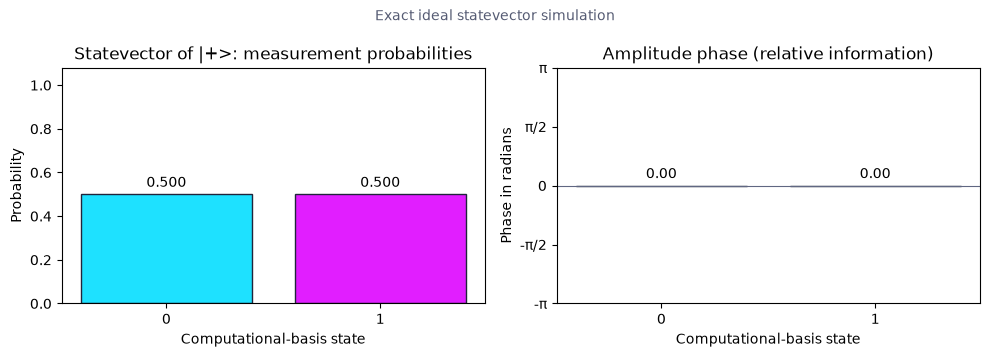

In [42]:
qc_sv = QuantumCircuit(1)
qc_sv.h(0)
psi = aer_statevector(qc_sv)
show_statevector(psi, ["0", "1"], "Statevector of |+>")

# Part V - Entanglement lab

## 15. Bell pair

Starting from $|00\rangle$:
1. apply H to qubit 0;
2. apply CNOT with qubit 0 as control and qubit 1 as target.

The ideal state becomes

$$|\Phi^+\rangle=\frac{|00\rangle+|11\rangle}{\sqrt2}.$$

The outcomes are random but correlated: ideal measurement produces only `00` and `11`.

Bell state amplitudes
|00> : +0.7071+0.0000j   P=0.5000
|01> : +0.0000+0.0000j   P=0.0000
|10> : +0.0000+0.0000j   P=0.0000
|11> : +0.7071+0.0000j   P=0.5000


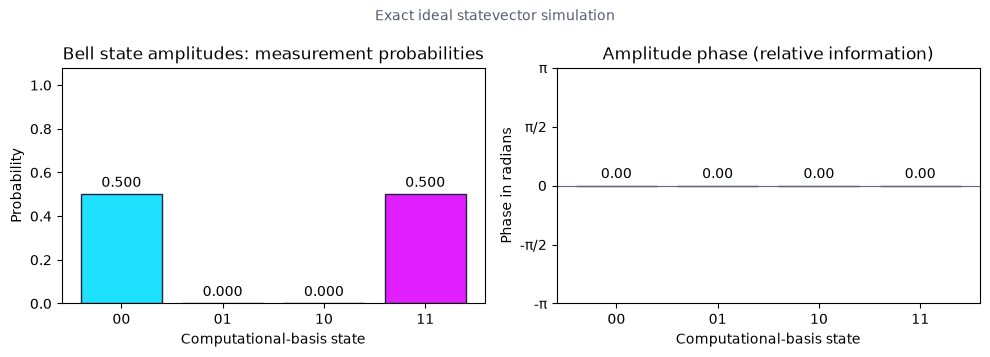

In [43]:
# Statevector first, before measurement
bell_state = QuantumCircuit(2)
bell_state.h(0)
bell_state.cx(0, 1)
psi_bell = aer_statevector(bell_state)
show_statevector(psi_bell, ["00", "01", "10", "11"], "Bell state amplitudes")

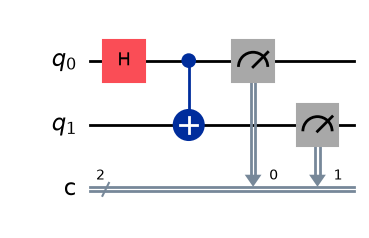

{'11': 1017, '00': 983}


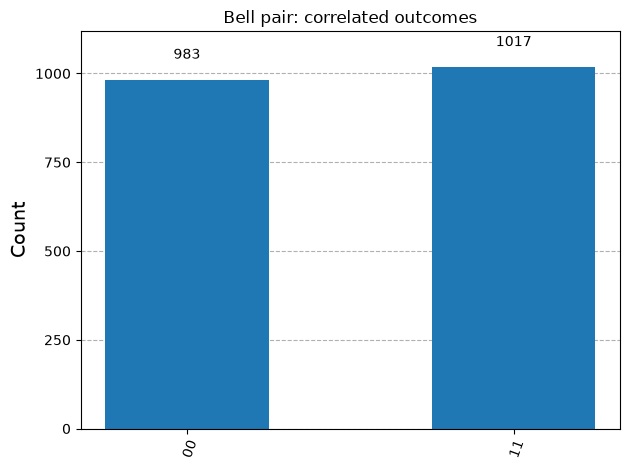

In [44]:
# Now measure the Bell pair many times.
bell = QuantumCircuit(2, 2)
bell.h(0)
bell.cx(0, 1)
bell.measure([0, 1], [0, 1])

counts_bell, *_ = run_counts(bell, shots=2000)
display(bell.draw("mpl"))
show_counts(counts_bell, "Bell pair: correlated outcomes")

### Qiskit bit ordering - common workshop confusion

Qiskit labels qubits and classical bits by index. When a multi-bit result is printed as a string, the highest classical-bit index appears on the left. Always say what each bit means before interpreting `01`, `10`, etc.

For this Bell circuit, either way the ideal correlation is easy to recognize because the only expected strings are `00` and `11`.

# Part VI - Grover search

## 16. The idea

Grover search is an **amplitude-amplification** algorithm for unstructured search.

For a search space of size $N$:
- classical unstructured search needs $O(N)$ oracle queries in the worst/average scaling sense;
- Grover needs $O(\sqrt{N})$ oracle queries.

For this workshop, two qubits represent four candidate states: `00`, `01`, `10`, `11`.

### Main terms
- **Oracle**: marks the desired state by changing its phase.
- **Diffusion operator**: reflects amplitudes about their average so the marked state's amplitude grows.
- **Amplitude amplification**: the broader pattern of increasing the probability of desired outcomes through interference.

## 17. Oracle for target |11>
A controlled-Z gate adds a minus sign to the $|11\rangle$ amplitude while leaving its immediate measurement probability unchanged.

Before oracle
|00> : +0.5000+0.0000j   P=0.2500
|01> : +0.5000+0.0000j   P=0.2500
|10> : +0.5000+0.0000j   P=0.2500
|11> : +0.5000+0.0000j   P=0.2500


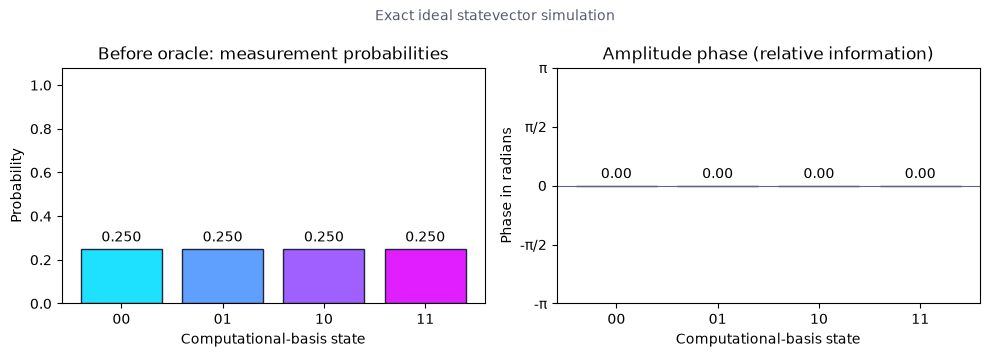

After oracle marks |11>
|00> : +0.5000+0.0000j   P=0.2500
|01> : +0.5000+0.0000j   P=0.2500
|10> : +0.5000+0.0000j   P=0.2500
|11> : -0.5000+0.0000j   P=0.2500


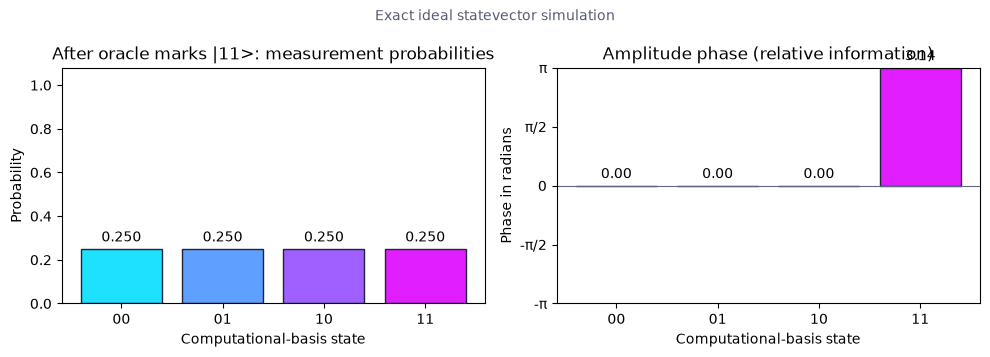

In [45]:
grover_oracle_demo = QuantumCircuit(2)
grover_oracle_demo.h([0, 1])
psi_before_oracle = aer_statevector(grover_oracle_demo)

grover_oracle_demo.cz(0, 1)
psi_after_oracle = aer_statevector(grover_oracle_demo)

show_statevector(psi_before_oracle, ["00", "01", "10", "11"], "Before oracle")
show_statevector(psi_after_oracle, ["00", "01", "10", "11"], "After oracle marks |11>")

## 18. Diffusion operator
For two qubits, the following sequence implements the standard inversion-about-the-mean step used in this workshop.

In [46]:
def diffuser_2q(qc):
    qc.h([0, 1])
    qc.x([0, 1])
    qc.cz(0, 1)
    qc.x([0, 1])
    qc.h([0, 1])
    return qc

## 19. Complete 2-qubit Grover search for |11>
One oracle-plus-diffusion iteration is enough for this four-state example.

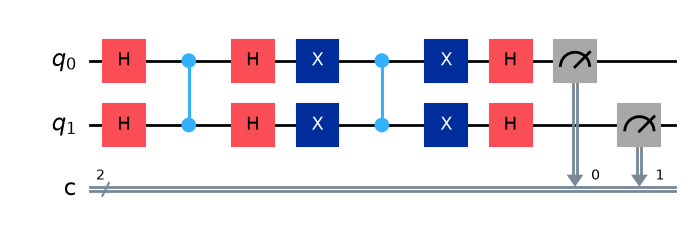

{'11': 1000}


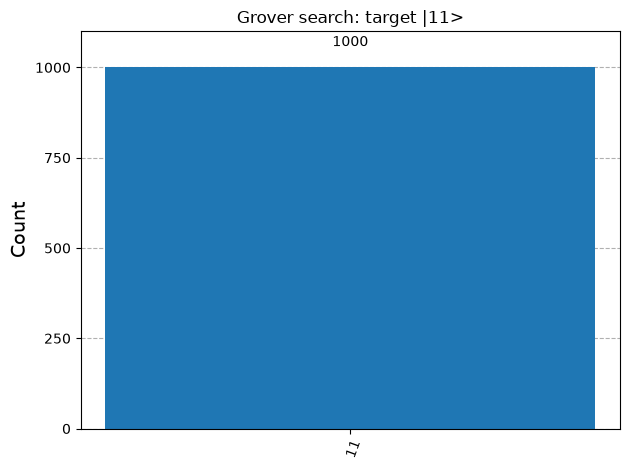

In [47]:
grover = QuantumCircuit(2, 2)

# 1) Equal superposition over 00, 01, 10, 11
grover.h([0, 1])

# 2) Oracle marks |11>
grover.cz(0, 1)

# 3) Diffusion amplifies the marked state
diffuser_2q(grover)

# 4) Measure
grover.measure([0, 1], [0, 1])

counts_grover, *_ = run_counts(grover, shots=1000)
display(grover.draw("mpl"))
show_counts(counts_grover, "Grover search: target |11>")

## 20. Advanced: make the 2-qubit oracle target selectable

To mark a basis state other than `11`, temporarily apply X gates to qubits where the desired target bit is 0, use CZ to mark the transformed `11`, then undo those X gates.

This helper uses target strings written in **Qiskit's displayed classical order** (`q1 q0`).

In [48]:
def mark_2q_target(qc, target):
    if target not in {"00", "01", "10", "11"}:
        raise ValueError("target must be one of 00, 01, 10, 11")

    # target is written q1 q0, so reverse it to address [q0, q1].
    target_by_qubit = target[::-1]
    zero_qubits = [q for q, bit in enumerate(target_by_qubit) if bit == "0"]

    for q in zero_qubits:
        qc.x(q)
    qc.cz(0, 1)
    for q in zero_qubits:
        qc.x(q)
    return qc


def grover_search_2q(target="11", shots=1000):
    qc = QuantumCircuit(2, 2)
    qc.h([0, 1])
    mark_2q_target(qc, target)
    diffuser_2q(qc)
    qc.measure([0, 1], [0, 1])
    counts, *_ = run_counts(qc, shots=shots)
    return qc, counts

for target in ["00", "01", "10", "11"]:
    _, counts = grover_search_2q(target, shots=500)
    winner = max(counts, key=counts.get)
    print(f"target={target} -> most frequent={winner}, counts={counts}")

target=00 -> most frequent=00, counts={'00': 500}
target=01 -> most frequent=01, counts={'01': 500}
target=10 -> most frequent=10, counts={'10': 500}
target=11 -> most frequent=11, counts={'11': 500}


# Part VII - Capstone: circuit-based random bits

## 21. What we are building

Circuit:

`|0> -> H -> measure -> 0 or 1`

On a physical quantum device, measurement can provide physical quantum randomness, subject to device bias, noise, health tests and entropy-extraction requirements.

In **this workshop**, Aer runs on a classical computer. It simulates the expected measurement statistics and uses classical pseudorandom sampling internally. Therefore Aer output is excellent for learning and testing, but it is **not** a production quantum entropy source.

In [49]:
def simulated_random_bit():
    qc = QuantumCircuit(1, 1)
    qc.h(0)
    qc.measure(0, 0)
    counts, *_ = run_counts(qc, shots=1, seed=None)
    return next(iter(counts))

print("One simulated random bit:", simulated_random_bit())

One simulated random bit: 0


## 22. Generate a whole random bitstring efficiently
Instead of building one circuit per bit, put $n$ qubits into superposition and measure them once.

In [50]:
def simulated_random_bits(n=16):
    qc = QuantumCircuit(n, n)
    qc.h(range(n))
    qc.measure(range(n), range(n))
    counts, *_ = run_counts(qc, shots=1, seed=None)
    return next(iter(counts))

bits = simulated_random_bits(16)
print("16 simulated bits:", bits)
print("As integer:", int(bits, 2))

16 simulated bits: 1001000100101111
As integer: 37167


## 23. Statistical sanity check
For an ideal H measurement, many shots should be close to 50/50. Finite samples will not be exactly equal.

counts: {'1': 5023, '0': 4977}
P(0)~0.4977, P(1)~0.5023


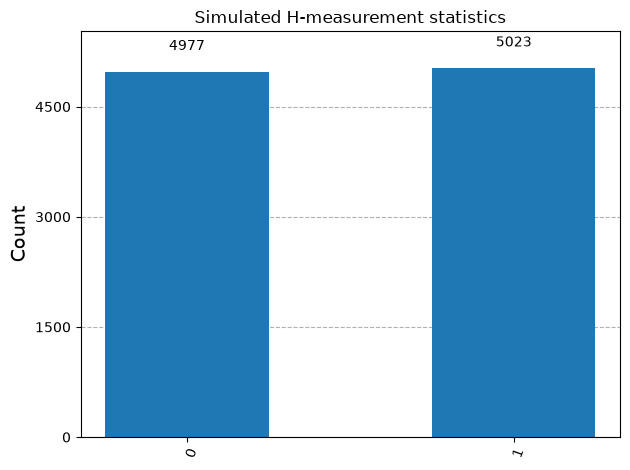

In [51]:
qc_rng_test = QuantumCircuit(1, 1)
qc_rng_test.h(0)
qc_rng_test.measure(0, 0)

shots = 10000
counts_rng, *_ = run_counts(qc_rng_test, shots=shots, seed=None)
p0 = counts_rng.get("0", 0) / shots
p1 = counts_rng.get("1", 0) / shots
print("counts:", counts_rng)
print(f"P(0)~{p0:.4f}, P(1)~{p1:.4f}")
display(plot_histogram(counts_rng, title="Simulated H-measurement statistics"))

# Part VIII - Ideal simulation vs noisy simulation

## 24. Why add noise?
Ideal Aer simulation follows the circuit model exactly. Real devices have physical errors such as:
- **relaxation**: energy loss, often summarized by a $T_1$ timescale;
- **dephasing**: loss of phase coherence, related to $T_2$;
- **gate error**: implemented operation differs from the requested operation;
- **readout error**: measurement reports the wrong classical bit.

Aer can deliberately inject noise models so we can study how errors change results.

Ideal: {'00': 1966, '11': 2034}
Noisy: {'11': 1975, '10': 43, '00': 1930, '01': 52}


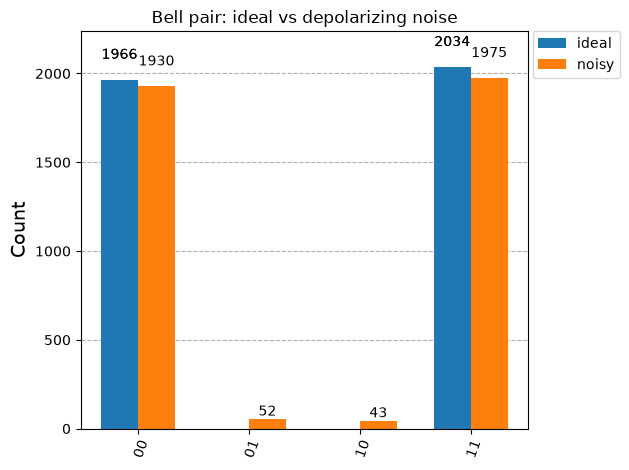

In [52]:
from qiskit_aer.noise import NoiseModel, depolarizing_error

noise_model = NoiseModel()
noise_model.add_all_qubit_quantum_error(
    depolarizing_error(0.02, 1), ["h"]
)
noise_model.add_all_qubit_quantum_error(
    depolarizing_error(0.05, 2), ["cx"]
)

noisy_sim = AerSimulator(noise_model=noise_model)

# Compare Bell-pair results.
ideal_counts, *_ = run_counts(bell, shots=4000, seed=42)
noisy_counts, *_ = run_counts(bell, shots=4000, seed=42, simulator=noisy_sim)

print("Ideal:", ideal_counts)
print("Noisy:", noisy_counts)
display(plot_histogram([ideal_counts, noisy_counts],
                       legend=["ideal", "noisy"],
                       title="Bell pair: ideal vs depolarizing noise"))

## 25. Aer Simulator vs physical QPU

| Dimension | Aer Simulator | Physical QPU |
|---|---|---|
| Execution | Classical CPU/GPU numerical simulation | Physical qubits |
| Noise | Ideal by default; configurable models | Physical noise is unavoidable |
| Statevector | Can be inspected in suitable simulations | Unknown full state cannot simply be read out |
| Scale | General statevector simulation grows exponentially | Hardware has physical qubits but limited fidelity/connectivity |
| Best use | Learning, debugging, algorithm development, tests | Hardware experiments and device behavior |

A useful quantum workflow is usually **hybrid**: classical software prepares, compiles, schedules, analyzes and iterates around quantum execution.

# Part IX - Debugging checklist

When a result looks wrong, ask these questions in order:

1. **Environment** - does `import qiskit_aer` work?
2. **Circuit width** - did you allocate enough qubits and classical bits?
3. **Measurement** - did you measure before asking for counts?
4. **State** - what state should exist immediately before measurement?
5. **Amplitude vs probability** - are you squaring magnitude before interpreting an amplitude?
6. **Phase** - did a phase gate change phase while leaving direct Z-basis probabilities unchanged?
7. **Bit ordering** - are you interpreting displayed bitstrings correctly?
8. **Shots** - is a small discrepancy simply finite-sampling variation?
9. **Noise** - are you comparing an ideal model to a noisy model or physical device?
10. **Transpilation** - are you inspecting the logical circuit or the backend-compiled circuit?

qubits       : 2
classical bits: 2
depth        : 3
operations   : OrderedDict({'measure': 2, 'h': 1, 'cx': 1})


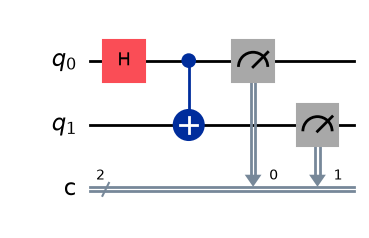

In [53]:
# A small diagnostic helper for workshop circuits.
def diagnose(circuit):
    print("qubits       :", circuit.num_qubits)
    print("classical bits:", circuit.num_clbits)
    print("depth        :", circuit.depth())
    print("operations   :", circuit.count_ops())
    display(circuit.draw("mpl"))

diagnose(bell)

# Part X - Knowledge check

Answer before running the solution cells at the end.

1. What is the difference between an amplitude and a probability?
2. Why can Z matter even if direct Z-basis probabilities do not change?
3. What does `shots=1024` mean?
4. Which two gates create the standard Bell pair from $|00\rangle$?
5. What is the role of the Grover oracle?
6. What does the diffusion operator do?
7. Why is a sampled Aer bit not the same thing as certified physical quantum entropy?
8. Why can a statevector simulator become expensive as qubit count grows?

# Part XI - Team challenges

## Challenge A - Bell + histogram
Build from memory:
- 2 qubits and 2 classical bits;
- H on q0;
- CX(q0, q1);
- measure both;
- 2,000 Aer shots;
- histogram;
- explain why `01` and `10` are absent in the ideal model.

In [54]:
# Challenge A workspace
# Write your circuit here.

## Challenge B - Phase detective
Create two one-qubit circuits:
- Circuit 1: H -> H -> measure
- Circuit 2: H -> Z -> H -> measure

Predict both outcomes before running them.

In [ ]:
# Challenge B workspace

## Challenge C - Grover target switch
Use `grover_search_2q()` to target `00`, `01`, `10`, and `11`. Explain how the oracle changes while the diffuser remains the same.

In [ ]:
# Challenge C workspace

## Challenge D - 32-bit simulated random string
Generate 32 bits with one Aer circuit and convert them to an integer.

In [ ]:
# Challenge D workspace

# Part XII - Full glossary

| Term | Workshop meaning |
|---|---|
| **Amplitude** | Complex coefficient of a basis state. Its squared magnitude gives measurement probability. |
| **Backend** | Target that executes a circuit, such as `AerSimulator`. |
| **Basis state** | A standard state such as $|0\rangle$, $|1\rangle$, or multi-qubit strings like $|01\rangle$. |
| **Bell state** | Maximally entangled two-qubit state such as $(|00\rangle+|11\rangle)/\sqrt2$. |
| **Bit** | Classical two-valued information unit. |
| **Bloch sphere** | Geometric representation of pure one-qubit states. |
| **Circuit** | Ordered sequence of quantum and classical instructions. |
| **Classical register** | Classical storage that receives measurement outcomes. |
| **CNOT / CX** | Controlled-X gate: conditionally flips a target qubit. |
| **Counts** | Frequency dictionary of sampled classical bitstrings. |
| **Diffusion operator** | Grover step that reflects amplitudes around their average. |
| **Entanglement** | Joint quantum state that cannot be factored into independent states of its parts. |
| **Gate** | Reversible quantum-state transformation. |
| **Global phase** | Overall complex phase multiplying the whole state; it does not affect measurement statistics. |
| **Hadamard (H)** | Gate used for basis change and equal-amplitude superposition from basis states. |
| **Interference** | Addition/cancellation of amplitudes based on relative phase. |
| **Job** | Submitted backend execution request. |
| **Measurement** | Operation producing classical outcomes according to quantum probabilities. |
| **Noise model** | Simulator model that injects specified errors. |
| **Oracle** | Algorithm-specific operation that marks information, often through phase. |
| **Phase** | Relative complex angle between amplitudes; affects interference. |
| **Probability** | Squared magnitude of an amplitude. |
| **QPU** | Quantum processing unit made from physical qubits. |
| **QRNG** | Quantum random number generator; a production version requires physical entropy plus engineering/validation. |
| **Qubit** | Quantum information unit described by amplitudes and phase. |
| **Result** | Backend output object returned when a job finishes. |
| **Shots** | Repeated samples of a measured circuit. |
| **Statevector** | Array of complex amplitudes for an ideal pure state. |
| **Superposition** | Coherent linear combination of basis states. |
| **Transpilation** | Circuit transformation for a target backend. |
| **Unitary** | Reversible norm-preserving linear operation representing an ideal quantum gate. |

# Part XIII - Suggested solutions

Open these only after attempting the challenges.

{'11': 1017, '00': 983}


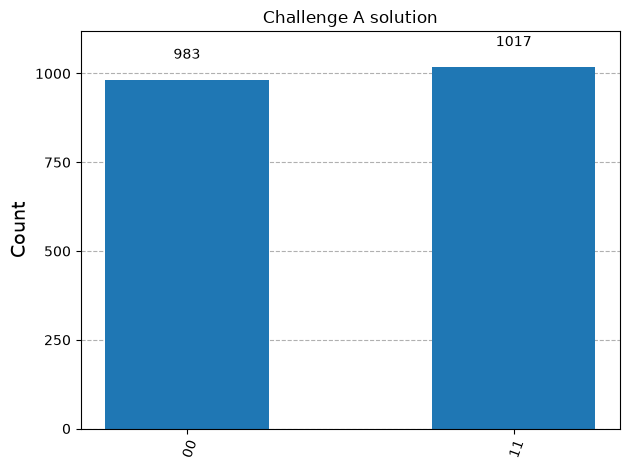

In [55]:
# Solution A - Bell + histogram
solution_a = QuantumCircuit(2, 2)
solution_a.h(0)
solution_a.cx(0, 1)
solution_a.measure([0, 1], [0, 1])
solution_a_counts, *_ = run_counts(solution_a, shots=2000)
show_counts(solution_a_counts, "Challenge A solution")

In [56]:
# Solution B - Phase detective
_, solution_b1 = interference_experiment(False, shots=500)
_, solution_b2 = interference_experiment(True, shots=500)
print("H-H   ->", solution_b1)
print("H-Z-H ->", solution_b2)

H-H   -> {'0': 500}
H-Z-H -> {'1': 500}


In [57]:
# Solution C - Grover targets
for target in ["00", "01", "10", "11"]:
    _, counts = grover_search_2q(target, shots=1000)
    print(target, "->", max(counts, key=counts.get), counts)

00 -> 00 {'00': 1000}
01 -> 01 {'01': 1000}
10 -> 10 {'10': 1000}
11 -> 11 {'11': 1000}


In [59]:
# # Solution D - 32 simulated bits
# solution_bits = simulated_random_bits(32)
# print(solution_bits)
# print(int(solution_bits, 2))

# Final recap

The workshop journey was:

**prepare -> transform -> entangle/interfere -> measure -> repeat -> interpret**

The most important mental model is:

> A quantum program controls amplitudes and relative phases so that interference changes which measurement outcomes are likely.

### Continue learning
- IBM Quantum Learning: https://quantum.cloud.ibm.com/learning
- Qiskit documentation: https://quantum.cloud.ibm.com/docs/en/api/qiskit
- Qiskit Aer simulation guide: https://quantum.cloud.ibm.com/docs/en/guides/simulate-with-qiskit-aer

### Next step
Rebuild the X, H, phase-interference, Bell, Grover and random-bit circuits without looking at this notebook. Then compare ideal Aer simulation with a noisy model and, when appropriate, with real hardware.